## CNN to predict which number was written

In this notebook, I will implement a CNN to analyze and predict a number. I will use a dataset from the tf library which contains plenty of numbers from 0 to 9, this means that the CNN
will have as an input an image and will have 10 neurons as an output.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
train, test = mnist.load_data()
X_train, y_train = train
X_test, y_test = test
print(f"The number of examples to train with are going to be {len(train[0])} and the size of each image is : {len(train[0][0])} x {len(train[0][0][0])}")

print(F"Since this image is a grey scale image we spect the maximum value in this image to be 255 (2^8 - 1) : {X_test[0].max()}")

The number of examples to train with are going to be 60000 and the size of each image is : 28 x 28
Since this image is a grey scale image we spect the maximum value in this image to be 255 (2^8 - 1) : 255


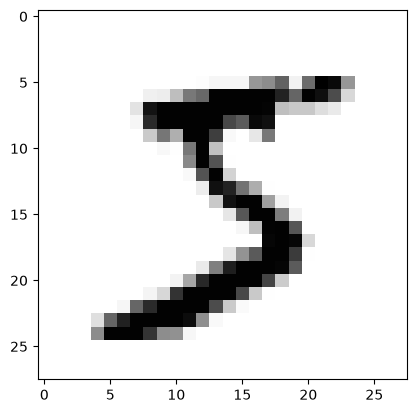

In [3]:
# Example for an image
from PIL import Image

im = Image.fromarray(X_train[0])
plt.figure()
plt.imshow(im, cmap="Greys")
plt.show()


### First of all
I would like to analyze which are the outputs of these images which are the second element of the tuple ("1 indexed") to know which type of data we're treating (I already know they are
going to be numbers from 0 to 9 but ok...)

In [4]:
from collections import Counter

numbers = Counter(train[1])

print(f"This are the number of appearions of each number: ")
y_train_values_toGraph = [[int(number), count] for number, count in numbers.items()]
y_train_values_toGraph.sort(key = lambda x: [x[0]])

print(y_train_values_toGraph)

use = lambda x, i: [pair[i] for pair in x]

This are the number of appearions of each number: 
[[0, 5923], [1, 6742], [2, 5958], [3, 6131], [4, 5842], [5, 5421], [6, 5918], [7, 6265], [8, 5851], [9, 5949]]


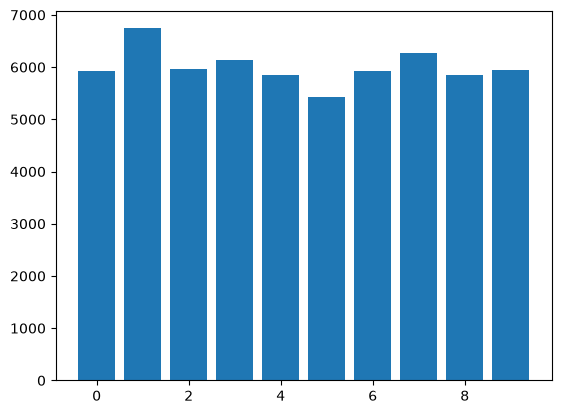

In [5]:
plt.figure()
plt.bar(use(y_train_values_toGraph,0), use(y_train_values_toGraph, 1))
plt.show()

As it can be seen, we are dealing with a classified 10 different output dataset, and the number of appearance of numbers are mostly equal, so we can start developing the model.

## Normalizing
It's important to note that these numbers are in grayscale (1 Channel from 0 to 255), but in this case, it is better to work with values between 0 to 1, this operation is NN friendly.

### How does this scale work?

$\displaystyle\sum_{l=0}^\mathrm{length} \displaystyle\sum_{w=0}^\mathrm{width} \frac{Image_{l, w}}{255}$

This formula divides every pixel by 255 since this image has only one channel, with a max value of 255 this will result on a array with numbers within 0 and 1.

In [6]:
normalize = lambda arr: arr / 255.0

X_train , X_test = normalize(X_train), normalize(X_test)

## Dimensions issue

A CNN will expect the following shape:

X_train.shape : (number_of_elements, height, width, n_channels)

Right now the shape is only (60_000, 28, 28) we are missing a 1

In [7]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)

(60000, 28, 28, 1)


## CREATING THE MODEL

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation= 'relu', input_shape = X_train.shape[1::]),
    MaxPool2D((2,2)),
    Conv2D(64, (3,3), activation= 'relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(64, activation= 'relu'),
    Dense(10, activation= 'softmax')
]);

model.summary()


/Users/emmanuel/DeVeLoP/AI-ML/CNN/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### WE COMPILE THE MODEL

As this model will be simple, I will like to keep it like it, we will use adam as most of cases will be the best option to reach max minima or near max minima, and the metric we will aim for will be accuracy, being the correct classifications over all the number of training elements.

In [9]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

## FINALLY We run the model

In [10]:
model.fit(
    X_train,
    y_train,
    epochs = 6,
    batch_size = 64,
    validation_split=0.1
)

Epoch 1/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9451 - loss: 0.1783 - val_accuracy: 0.9828 - val_loss: 0.0551
Epoch 2/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9832 - loss: 0.0542 - val_accuracy: 0.9870 - val_loss: 0.0401
Epoch 3/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9873 - loss: 0.0392 - val_accuracy: 0.9892 - val_loss: 0.0385
Epoch 4/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9911 - loss: 0.0289 - val_accuracy: 0.9880 - val_loss: 0.0396
Epoch 5/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9888 - val_loss: 0.0419
Epoch 6/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9938 - loss: 0.0178 - val_accuracy: 0.9893 - val_loss: 0.0430


## Let's see if the model was trained properly

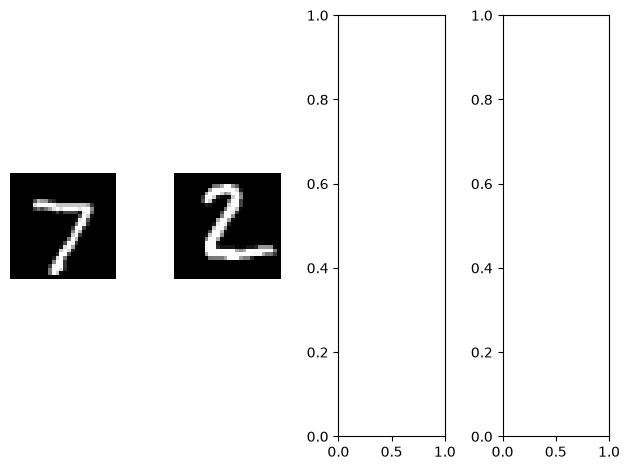

No explanations needed, this is a number 7 and 2, the model will be aproved if the number that's predicted is also a 7 and 2


In [11]:
numbers_to_predict = [image.reshape(28,28) * 255 for image in X_test[0:2]]
fig, axes = plt.subplots(1, 4)
for i, img in enumerate(numbers_to_predict):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("No explanations needed, this is a number 7 and 2, the model will be aproved if the number that's predicted is also a 7 and 2")

In [12]:
for pred in model.predict(X_test[0:2]):
    print(pred.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
7
2


In [13]:
corrects = 0
test_size = len(y_test)

for i, pred in enumerate(model.predict(X_test)):
    if y_test[i] == pred.argmax():
        corrects += 1

print(corrects * 100 / test_size, '%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
98.97 %


## Results:

This simple model was able to predict written numbers with a proper assignment to its value, the model itself reached an accuracy of ~ 99% which is a great prediction.

__Note That__ the model received a total of 28 * 28 features and 1 channel and the model returned a 5 * 5 features and 64 channels this meaning that for this case what was the most important element was the capacity of the model to detect shapes whithin the image.

I hope this explanations will result usefull for someone starting into Deep Learning or AI/ML